<a href="https://colab.research.google.com/github/updalla-apshir/machine-learning-projects/blob/main/Project_3_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score
from xgboost import XGBRegressor


In [ ]:
house_data = fetch_openml('boston', version=1, as_frame=True)

In [ ]:
X = house_data.data
Y = house_data.target

Data Preprocessing

In [ ]:
# checking the data if have any null values
print(X.isnull().sum())
print(Y.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64
0


In [ ]:
# statistical measures of the data
X.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000


## Correlation
1. Positive Correlation
2. Negative Correlation

In [ ]:
# concatenate X and Y
df = pd.concat([X,Y],axis=1)

In [ ]:
corr = df.corr()

<Axes: >

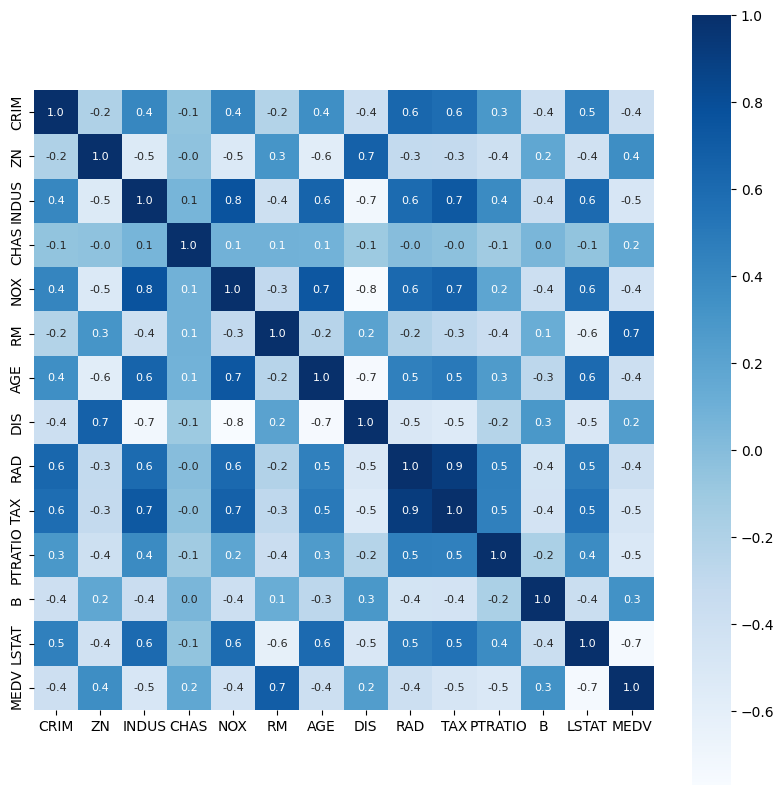

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(corr,cmap='Blues',fmt='.1f',annot_kws={'size':8},square=True, annot=True,cbar=True)


## Spliting to the Training and Testing Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(506, 13) (404, 13) (102, 13)


# Model Training

XGBoost Regressor

In [ ]:
# loading the model
model = XGBRegressor()

In [ ]:
# feeding the model
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# predicting the training data
training_data_prediction = model.predict(X_train)

In [ ]:
# predict the testing data
test_data_prediction = model.predict(X_test)

Evaluation

In [ ]:
# R squared error
score_1 = r2_score(Y_train, training_data_prediction)

# Mean Absolute Error
score_2 = mean_absolute_error(Y_train, training_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9999971466552331
Mean Absolute Error :  0.011136001643567985


In [ ]:
# R squared error
score_1 = r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_2 = mean_absolute_error(Y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.8866857076120187
Mean Absolute Error :  2.196387175017712


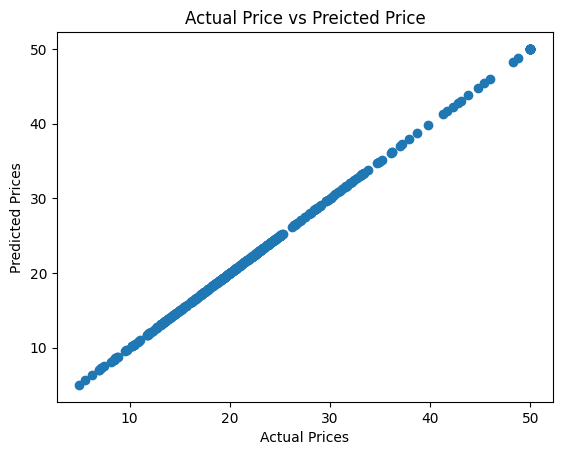

In [ ]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Preicted Price")
plt.show()

In [ ]:
# prediction system
input_data = (0.14455, 12.5, 7.87, 0, 0.524, 6.172, 96.1, 5.9505, 5, 311.0, 15.2, 396.9, 19.15)

#input as array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)

In [ ]:
print(prediction)

[27.070108]


In [ ]:
values = X.iloc[7]
print(', '.join(map(str,values)))

0.14455, 12.5, 7.87, 0, 0.524, 6.172, 96.1, 5.9505, 5, 311.0, 15.2, 396.9, 19.15


In [ ]:
Y[7]

np.float64(27.1)